In [2]:
%load_ext autoreload
%autoreload 2

from pathlib import Path 
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
from tqdm import tqdm
from IPython.display import Video

import torch
import numpy as np

import sys
sys.path.append("/mnt/home/focus")

os.chdir("/mnt/home/focus")
print(f"Working directory: {os.getcwd()}")

import env
from env.make import make

import matplotlib.pyplot as plt
import matplotlib.animation as animation

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Working directory: /mnt/home/focus


In [3]:
from hydra import compose, initialize
from omegaconf import OmegaConf

initialize(config_path="../../../../public/projects/mazpie/focus_skill_dmc_sweep_distance_mode_coordConv/pretrain/41a31fc2cd0e0ccf75b1449541cc2694/code/exp_local/2024.01.02/143841_skill_focus_reacher_hard_/.hydra", job_name="config")
cfg = compose(config_name="config")

/tmp/ipykernel_4017/725984538.py:4: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  initialize(config_path="../../../../public/projects/mazpie/focus_skill_dmc_sweep_distance_mode_coordConv/pretrain/41a31fc2cd0e0ccf75b1449541cc2694/code/exp_local/2024.01.02/143841_skill_focus_reacher_hard_/.hydra", job_name="config")


In [4]:
obs_type = "pixels"
global_step = 0
action_repeat = 2
snapshot_ts = global_step * action_repeat
seed = 0

domain = "dmc"  
task = "reacher_hard"

# Env creation
env = make(cfg.domain, cfg.task, obs_type, frame_stack=1, 
                    action_repeat=action_repeat, seed=seed, env_config=cfg.env)

env.reset()

/opt/conda/lib/python3.11/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3483.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


final text_encoder_type: bert-base-uncased
Hyperparameters read from the model weights: C^k=64, C^v=512, C^h=64
Single object mode: False


/opt/conda/lib/python3.11/site-packages/transformers/modeling_utils.py:907: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torch/utils/checkpoint.py:31: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn("None of the inputs have requires_grad=True. Gradients will be None")
/mnt/home/focus/env/tracker/base_tracker.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, device=self.device)


{'reward': 0.0,
 'is_first': True,
 'is_last': False,
 'is_terminal': False,
 'rgb': array([[[ 37,  37,  38, ...,  38,  38,  37],
         [ 38,  39,  39, ...,  73,  73,  38],
         [ 38,  39,  39, ...,  74,  73,  38],
         ...,
         [ 38,  73,  73, ...,  39,  39,  38],
         [ 37,  72,  73, ...,  39,  39,  37],
         [ 37,  37,  38, ...,  38,  37,  37]],
 
        [[ 62,  62,  62, ...,  62,  62,  62],
         [ 62,  78,  78, ..., 110, 110,  62],
         [ 62,  78,  78, ..., 112, 110,  62],
         ...,
         [ 62, 110, 111, ...,  78,  78,  62],
         [ 62, 110, 110, ...,  78,  78,  62],
         [ 62,  62,  62, ...,  62,  62,  62]],
 
        [[ 86,  86,  87, ...,  87,  86,  86],
         [ 86, 115, 115, ..., 149, 149,  86],
         [ 87, 115, 115, ..., 150, 149,  87],
         ...,
         [ 87, 149, 150, ..., 115, 115,  87],
         [ 86, 148, 149, ..., 115, 115,  86],
         [ 86,  86,  87, ...,  87,  86,  86]]], dtype=uint8),
 'proprio': array([     

In [9]:
# Import agent model (WM + Actor Critic)
agent_path = Path(f'/mnt/public/projects/mazpie/focus_skill_dmc_sweep_distance_mode_coordConv/pretrained_models/skill_focus/dmc/reacher_hard/1/snapshot_500000.pt')

def load_agent(agent_path):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    with agent_path.open('rb') as f:
        obj = torch.load(f, map_location=torch.device(device))
        agent = obj['agent']    
        step = obj['_global_step']
    return agent, step

def init_agent(cfg):
    from dreamer_pretrain import make_dreamer_agent
    return make_dreamer_agent(env.obs_space, env.action_spec(), cfg, cfg.agent)

agent = load_agent(agent_path)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
agent.device = device
agent.wm.device = device
agent.wm.rssm.device = device
agent.wm.rssm._cell.device = device
agent.is_finetune = True
agent.wm.rssm._full_posterior = True
agent.cfg.agent.only_expl_during_training = False

Encoder CNN inputs: ['rgb']
Encoder MLP inputs: ['proprio']
Decoder CNN outputs: []
Decoder MLP outputs: ['proprio']
Decoder CNN outputs: ['rgb', 'segmentation']
Decoder MLP outputs: ['objects_pos']
Object Encoder CNN inputs: []
Object Encoder MLP inputs: ['objects_pos']


-3.14
-2.8094736842105266
-2.4789473684210526
-2.148421052631579
-1.8178947368421052
-1.4873684210526315
-1.156842105263158
-0.8263157894736839
-0.49578947368421034
-0.16526315789473678
0.16526315789473722
0.4957894736842108
0.8263157894736843
1.156842105263158
1.4873684210526323
1.817894736842106
2.1484210526315795
2.478947368421053
2.8094736842105266
3.14


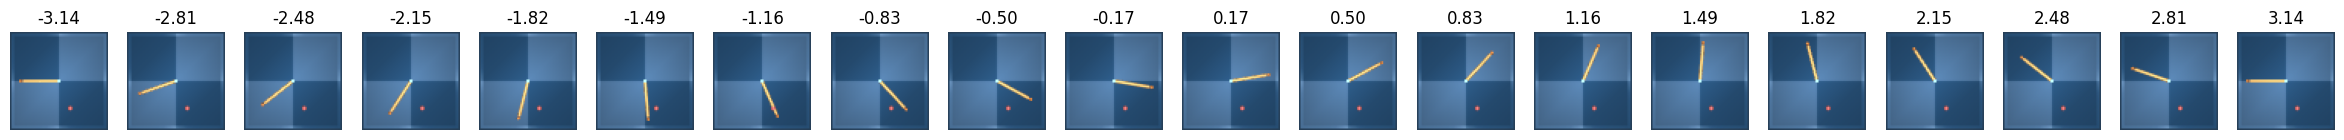

In [6]:
import matplotlib.pyplot as plt

env.reset()
# 1 - sample position uniformelly distributed along one axis of the workspace
x_pos = np.linspace(-3.14, 3.14, num=20)

# 2 - Get observations from the environment with the sampled position
pos_dict = {}
for pos in x_pos:
    print(pos)
    env.set_goal_state([pos, 0])
    pos_dict[pos] = env.step([0,0])
    

# 2.a - debug: plot the rgb observations
fig, ax = plt.subplots(1, len(pos_dict), figsize=(30, 10))
for i in range(len(pos_dict)):
    ax[i].imshow(pos_dict[x_pos[i]]["rgb"].transpose(1,2,0))
    ax[i].set_title(f"{x_pos[i]:.2f}")
    ax[i].axis('off')    
    

In [10]:
obs = env.reset()
meta = agent.init_meta()
meta["use_skill_behaviour"] = True
step, total_reward = 0, 0
agent_state = None
eval_mode = False
# start-up agent with one env episode
with torch.no_grad():
        while not bool(obs['is_last']):
            action, agent_state = agent.act(
                                    obs,
                                    meta,
                                    step,
                                    eval_mode=eval_mode,
                                    state=agent_state,
                                )
            obs = env.step(action)
            
            feat = agent.wm.rssm.get_feat(agent_state[0]).unsqueeze(0)

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x2136 and 1936x200)

In [28]:
# 3- Feed observations to the encoder and get object features, collect features in a list
feat = []
act_feat = []
obj_feat = []
agent_state = None
env.reset()
i = 0

# for pos, obs in pos_dict.items():
while i < 20:
    i += 1
    pos = x_pos[0]
    obs = pos_dict[x_pos[0]]
    print(pos)
    # obs = torch.from_numpy(obs["rgb"].copy()).unsqueeze(0).float().to(agent.device)
    tensor_obs = {
            k: torch.as_tensor(np.copy(v), device=agent.device).unsqueeze(0)
            for k, v in obs.items()
        }
    
    with torch.no_grad():
        # initialize latent state for each observation, fake zero action
        latent = agent.wm.rssm.initial(len(tensor_obs["reward"]))
        action = torch.zeros(
            (len(tensor_obs["reward"]),) + agent.act_spec.shape, device=agent.device
        )
        
        embed = agent.wm.encoder(agent.wm.preprocess(tensor_obs))
        should_sample = (not eval_mode) or (not agent.cfg.eval_state_mean)
        latent, _ = agent.wm.rssm.obs_step(
            latent, action, embed, tensor_obs["is_first"], should_sample
        )
        
        feat.append(embed.cpu().numpy()[0])

        a_f = agent.wm.rssm.get_feat(latent).unsqueeze(0)
        act_feat.append(a_f.cpu().numpy()[0])
        
        o_f = agent.wm.heads["object_decoder"].object_latent_extractor(a_f)["post"]["mean"]
        obj_feat.append(o_f.cpu().numpy()[0])
            
feat, act_feat, obj_feat = np.array(feat), np.array(act_feat)[:,0], np.array(obj_feat)[:,0,0]

print(feat.shape)
print(act_feat.shape)
print(obj_feat.shape)

/opt/conda/lib/python3.11/site-packages/transformers/modeling_utils.py:907: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torch/utils/checkpoint.py:31: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn("None of the inputs have requires_grad=True. Gradients will be None")
/mnt/home/focus/env/tracker/base_tracker.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, device=self.device)


-3.14
-3.14
-3.14
-3.14
-3.14
-3.14
-3.14
-3.14
-3.14
-3.14
-3.14
-3.14
-3.14
-3.14
-3.14
-3.14
-3.14
-3.14
-3.14
-3.14
(20, 1936)
(20, 1224)
(20, 1536)


In [32]:
# 4 - t-SNE plot the features
from sklearn.manifold import TSNE
feat_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=10).fit_transform(feat)
act_feat_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=10).fit_transform(act_feat)
obj_feat_embedded = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=10).fit_transform(obj_feat)

Text(0.5, 1.0, 'Object features')

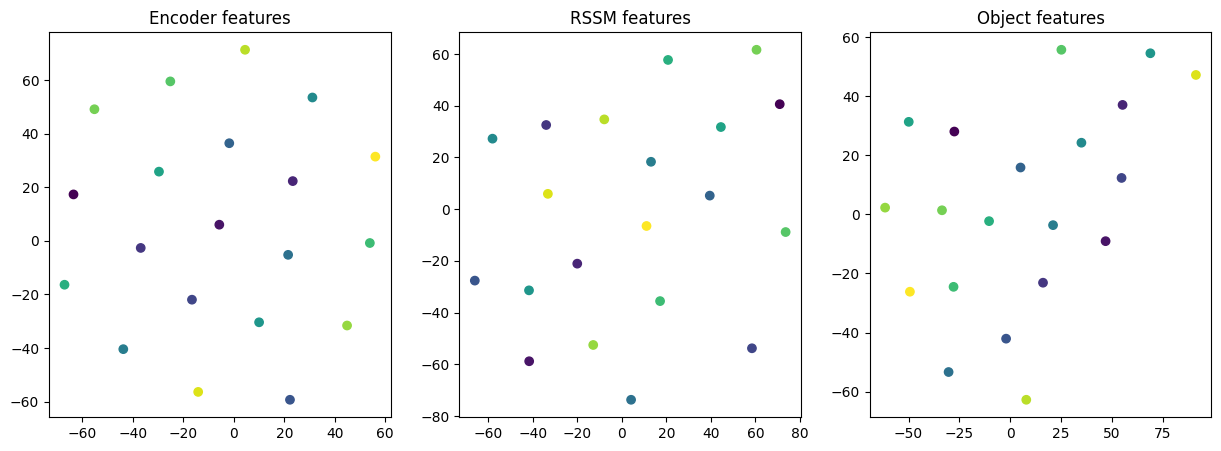

In [33]:
# 5 - associate each feature with a color that depens on the position along one axis

pos_list = np.fromiter(pos_dict.keys(), dtype=float)

# color_list = []
# for items in pos_dict.values():
    # color_list.append([0, *list((items["objects_pos"][0]))])
    
# print(color_list)
# print(color_list.shape)
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].scatter(feat_embedded[:,0], feat_embedded[:,1], c=pos_list)
axs[0].set_title("Encoder features")
axs[1].scatter(act_feat_embedded[:,0], act_feat_embedded[:,1], c=pos_list)
axs[1].set_title("RSSM features")
axs[2].scatter(obj_feat_embedded[:,0], obj_feat_embedded[:,1], c=pos_list)
axs[2].set_title("Object features")

{'encoder features': tensor([65.6893, 37.6485, 35.0769, 31.2963, 28.2520, 22.8966, 22.3297, 18.9017, 14.4458, 11.1177, 10.8231,  8.4319,  6.8998,  5.8937,  5.6901,  5.0692,  3.4543,  2.8504,  2.4527,  1.5753]), 'RSSM features': tensor([31.1396,  9.7705,  8.7730,  6.4040,  5.6555,  5.1755,  4.6364,  4.5638,  4.1660,  3.8841,  3.6649,  3.5570,  3.3910,  3.2962,  3.0398,  2.7372,  2.6663,  2.6106,  2.4304,  2.2138]), 'object features': tensor([36.4295, 17.4683, 16.3872, 15.6824, 13.4073,  9.8912,  8.7119,  3.2134,  2.3498,  1.7741,  1.5709,  1.4200,  1.1816,  0.9182,  0.7592,  0.7205,  0.6619,  0.5975,  0.4884,  0.4476])}


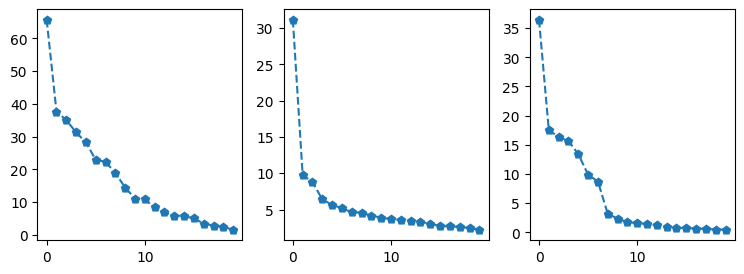

In [10]:
# Check relevant axis for position in the object's features -> ablation to check if there are major axis that are relevant for the position
d = {}

_, d["encoder features"], _ = torch.svd(torch.tensor(feat), compute_uv=False)
_, d["RSSM features"], _ = torch.svd(torch.tensor(act_feat), compute_uv=False)
_, d["object features"], _ = torch.svd(torch.tensor(obj_feat), compute_uv=False)

print(d)
fig, axs = plt.subplots(1, 3, figsize=(3*3,3))

axs[0].plot(d["encoder features"][:20], marker=(5, 0), linestyle='--')
axs[1].plot(d["RSSM features"][:20], marker=(5, 0), linestyle='--')
axs[2].plot(d["object features"][:20], marker=(5, 0), linestyle='--')

# TSNE only relative to those features

In [21]:
# 3- Feed observations to the encoder and get object features, collect features in a list
feat = []
act_feat = []
obj_feat = []
rgb_video = []
obs = env.reset()
rgb_video.append(obs["rgb"].transpose(1,2,0))

meta = agent.init_meta()
step, total_reward = 0, 0
agent_state = None
eval_mode = True
obj_pos_list = []

# start-up agent with one env episode
with torch.no_grad():
    while not bool(obs['is_last']):
        # obs = torch.from_numpy(obs["rgb"].copy()).unsqueeze(0).float().to(agent.device)
        tensor_obs = {
            k: torch.as_tensor(np.copy(v), device=agent.device).unsqueeze(0)
            for k, v in obs.items()
        }
    
        f = agent.wm.encoder(agent.wm.preprocess(tensor_obs))
        feat.append(f.cpu().numpy()[0])
        
        action, agent_state = agent.act(
                                obs,
                                meta,
                                step,
                                eval_mode=eval_mode,
                                state=agent_state,
                            )
        obs = env.step(action)
        obj_pos_list.append(obs["objects_pos"][0])
        rgb_video.append(obs["rgb"].transpose(1,2,0))
        
        # agent_state = (agent_state[0], torch.tensor(pos))
        # should update the agent state with the action that lead to the next state, otherwise, 
        # rssm expects to have a continuity betweeen consenquent state|action pairs
        
        a_f = agent.wm.rssm.get_feat(agent_state[0]).unsqueeze(0)
        act_feat.append(a_f.cpu().numpy()[0])
        
        o_f = agent.wm.heads["object_decoder"].object_latent_extractor(a_f)["post"]["mean"]
        obj_feat.append(o_f.cpu().numpy()[0])
            
feat, act_feat, obj_feat = np.array(feat), np.array(act_feat)[:,0], np.array(obj_feat)[:,0,0]
obj_pos_list, rgb_video = np.array(obj_pos_list), np.array(rgb_video)

print(feat.shape)
print(act_feat.shape)
print(obj_feat.shape)
print(obj_pos_list.shape)
print(rgb_video.shape)

/opt/conda/lib/python3.11/site-packages/transformers/modeling_utils.py:907: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/torch/utils/checkpoint.py:31: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn("None of the inputs have requires_grad=True. Gradients will be None")
/mnt/home/focus/env/tracker/base_tracker.py:91: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  mask = torch.tensor(mask, device=self.device)


(125, 1936)
(125, 1224)
(125, 1536)
(125, 2)
(126, 64, 64, 3)


In [22]:

import imageio; 
from IPython.display import Video; 

imageio.mimwrite('test2.mp4', rgb_video, fps=15) 
# Video('test2.mp4', width=128, height=128)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


[[0.0, 0, 0.6444444060325623], [0.13551402, 0, 0.7333332896232605], [0.2990654, 0, 0.6888887584209442], [0.45327103, 0, 0.4222222566604614], [0.53271025, 0, 0.599999874830246], [0.60280377, 0, 1.0], [0.7102804, 0, 0.7555555701255798], [0.8084113, 0, 0.7777776718139648], [0.9065421, 0, 0.7111110389232635], [0.9252337, 0, 0.2666667103767395], [0.9252337, 0, 0.48888885974884033], [0.9205608, 0, 0.24444442987442017], [0.9205608, 0, 0.48888885974884033], [0.93925244, 0, 0.5333332419395447], [0.91121495, 0, 0.2888888120651245], [0.93457943, 0, 0.4222222566604614], [0.9065421, 0, 0.24444442987442017], [0.93457943, 0, 0.4222222566604614], [0.96261686, 0, 0.15555554628372192], [0.9766355, 0, 0.37777769565582275], [0.98130846, 0, 0.11111098527908325], [0.99065423, 0, 0.31111109256744385], [0.9719627, 0, 0.1333332657814026], [0.96261686, 0, 0.44444435834884644], [0.9532711, 0, 0.2666667103767395], [0.94859815, 0, 0.5333332419395447], [0.94392526, 0, 0.3333333134651184], [0.94392526, 0, 0.57777777

Text(0.5, 1.0, 'Object features')

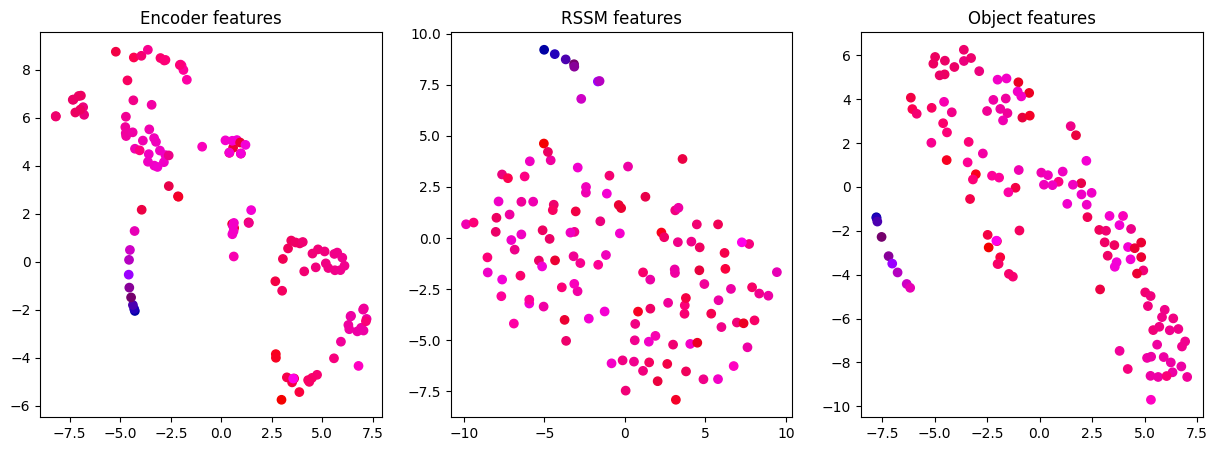

In [23]:
from sklearn.manifold import TSNE
feat_embedded = TSNE(n_components=2, init='random').fit_transform(feat)
act_feat_embedded = TSNE(n_components=2, init='random').fit_transform(act_feat)
obj_feat_embedded = TSNE(n_components=2, init='random').fit_transform(obj_feat)
pos_list = np.linspace(-1, 1, num=feat.shape[0])

# normalize the position along the axis
norm_obj_pos_list = np.zeros_like(obj_pos_list)
norm_obj_pos_list[:,0] = (obj_pos_list[:,0] - obj_pos_list[:,0].min()) / (obj_pos_list[:,0].max() - obj_pos_list[:,0].min())
norm_obj_pos_list[:,1] = (obj_pos_list[:,1] - obj_pos_list[:,1].min()) / (obj_pos_list[:,1].max() - obj_pos_list[:,1].min())

color = []
for i in range(feat.shape[0]):
    color.append([norm_obj_pos_list[i][0], 0, 1-norm_obj_pos_list[i][1]])
print(color)

fig, axs = plt.subplots(1, 3, figsize=(15, 5)) #, subplot_kw=dict(projection='3d'))
axs[0].scatter(feat_embedded[:,0], feat_embedded[:,1], c=color)
axs[0].set_title("Encoder features")
axs[1].scatter(act_feat_embedded[:,0], act_feat_embedded[:,1], c=color)
axs[1].set_title("RSSM features")
axs[2].scatter(obj_feat_embedded[:,0], obj_feat_embedded[:,1], c=color)
axs[2].set_title("Object features")

In [45]:
import cv2

for step, rgb in enumerate(rgb_video):
    fig.canvas.draw()
    data = np.array(fig.canvas.buffer_rgba(), dtype=np.uint8)[:,:,:3]
    # print(data.shape)
    data = cv2.resize(data, dsize=(192, 64), interpolation=cv2.INTER_CUBIC)

    # print(data.shape)
    # print(rgb.shape)
    
    if step==0:
        video = np.expand_dims(np.hstack([rgb, data]), axis=0) 
    else:
        curr_frame = np.expand_dims(np.hstack([rgb, data]), axis=0)
        # print(curr_frame.shape)
        video = np.concatenate([video, curr_frame], axis=0)    
            

In [46]:
import imageio; 
from IPython.display import Video; 

imageio.mimwrite('test2.mp4', video, fps=30)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


{'encoder features': tensor([2.9422e+02, 8.5973e+01, 6.0153e+01, 3.9506e+01, 2.5295e+01, 2.2699e+01, 1.4082e+01, 9.6880e+00, 9.0221e+00, 7.4947e+00, 5.4047e+00, 4.5688e+00, 3.9353e+00, 3.6278e+00, 3.0327e+00, 2.8965e+00, 2.4570e+00, 2.3368e+00, 2.1526e+00, 2.0309e+00, 1.8703e+00, 1.7605e+00, 1.6842e+00, 1.5973e+00, 1.4770e+00, 1.4158e+00,
        1.2850e+00, 1.2354e+00, 1.1502e+00, 1.0461e+00, 9.3517e-01, 9.0965e-01, 8.8090e-01, 7.6287e-01, 6.3179e-01, 6.1150e-01, 5.6434e-01, 5.3415e-01, 5.1659e-01, 4.6483e-01, 4.4336e-01, 4.2207e-01, 4.0439e-01, 3.7060e-01, 3.4519e-01, 3.3741e-01, 3.1433e-01, 3.0474e-01, 2.6770e-01, 2.5102e-01, 2.3840e-01, 2.3040e-01,
        2.2256e-01, 2.1544e-01, 1.9778e-01, 1.8977e-01, 1.8212e-01, 1.7123e-01, 1.6358e-01, 1.5771e-01, 1.5237e-01, 1.3860e-01, 1.3457e-01, 1.3278e-01, 1.2998e-01, 1.2089e-01, 1.1426e-01, 1.1298e-01, 1.1017e-01, 1.0138e-01, 9.6777e-02, 9.2251e-02, 8.7078e-02, 8.4084e-02, 7.7544e-02, 7.6495e-02, 7.2805e-02, 7.0226e-02,
        6.3887e-02,

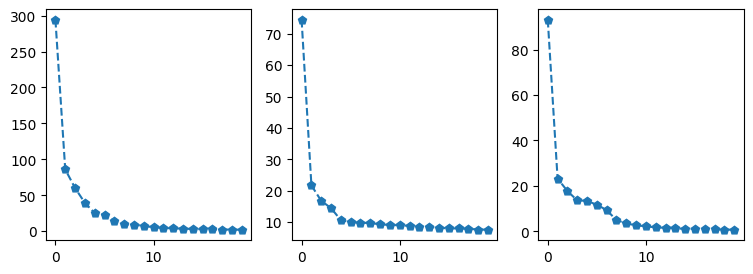

In [51]:
# Check relevant axis for position in the object's features -> ablation to check if there are major axis that are relevant for the position
d = {}

_, d["encoder features"], _ = torch.svd(torch.tensor(feat), compute_uv=False)
_, d["RSSM features"], _ = torch.svd(torch.tensor(act_feat), compute_uv=False)
_, d["object features"], _ = torch.svd(torch.tensor(obj_feat), compute_uv=False)

print(d)
fig, axs = plt.subplots(1, 3, figsize=(3*3,3))

axs[0].plot(d["encoder features"][:20], marker=(5, 0), linestyle='--')
axs[1].plot(d["RSSM features"][:20], marker=(5, 0), linestyle='--')
axs[2].plot(d["object features"][:20], marker=(5, 0), linestyle='--')

# TSNE only relative to those features